# 🧠 Midterm Project: Mushroom Classification
# 👤 Kersha Broussard
# 📅 Date: March 25, 2025

"""
This project applies classification modeling techniques to predict whether a mushroom is edible or poisonous based on its characteristics. 
We will explore the dataset, clean and prepare the features, train classification models, evaluate performance, and reflect on the results.
"""


In [1]:
# 📦 Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [4]:
import os
os.getcwd()

'C:\\Projects\\applied-ml-kersha\\midterm'

In [5]:
os.listdir(".")

['.ipynb_checkpoints', 'data', 'Untitled.ipynb']

# Section 1. Import and Inspect the Data

In [13]:
# Section 1.1 – Load the dataset and display the first 10 rows

df = pd.read_csv("mushrooms.csv", header=None, names=column_names)
df.head(10)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


In [14]:
# Section 1.2 – Check for missing values and display summary statistics

# Check for missing values
missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0])

# Check for any unusual placeholders (e.g., '?')
print("\nUnusual Characters Count:")
for col in df.columns:
    print(f"{col}: {(df[col] == '?').sum()}")

# Summary statistics for all columns
df.describe(include='all').T


Missing Values:
 Series([], dtype: int64)

Unusual Characters Count:
class: 0
cap-shape: 0
cap-surface: 0
cap-color: 0
bruises: 0
odor: 0
gill-attachment: 0
gill-spacing: 0
gill-size: 0
gill-color: 0
stalk-shape: 0
stalk-root: 2480
stalk-surface-above-ring: 0
stalk-surface-below-ring: 0
stalk-color-above-ring: 0
stalk-color-below-ring: 0
veil-type: 0
veil-color: 0
ring-number: 0
ring-type: 0
spore-print-color: 0
population: 0
habitat: 0


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


### 🧠 Reflection 1: Initial Observations

* What do you notice about the dataset? Are there any data issues?

The dataset does not contain any standard missing values (`NaN`), which is great. However, the `stalk-root` column contains 2,480 values represented by the `'?'` character, which will require cleaning or imputation.

All other features appear to be complete with no unusual missing markers. Given the categorical nature of most features, encoding and value distribution analysis will be important in the next step. No major data issues were found outside of the placeholder issue in `stalk-root`.


# Section 2. Data Exploration and Preparation

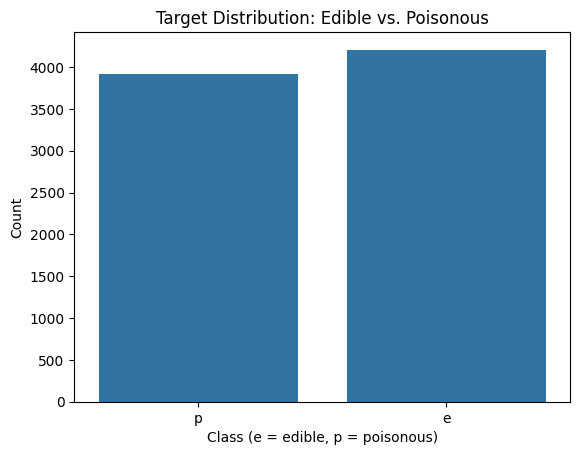

class
e    4208
p    3916
Name: count, dtype: int64

In [15]:
### Section 2.1 – Explore Data Patterns and Distributions
# Check class distribution (edible vs. poisonous)
sns.countplot(x='class', data=df)
plt.title("Target Distribution: Edible vs. Poisonous")
plt.xlabel("Class (e = edible, p = poisonous)")
plt.ylabel("Count")
plt.show()

# Print class counts for numeric reference
df['class'].value_counts()


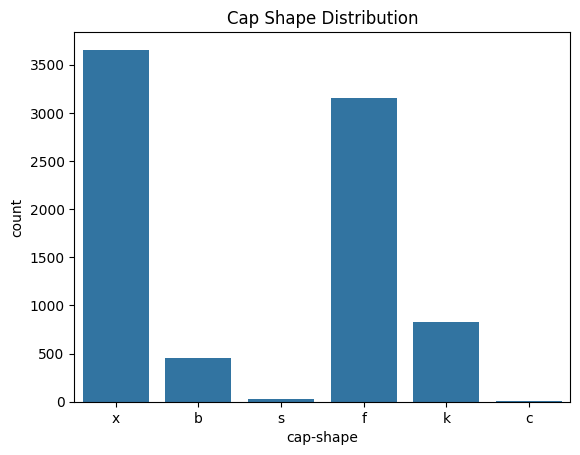

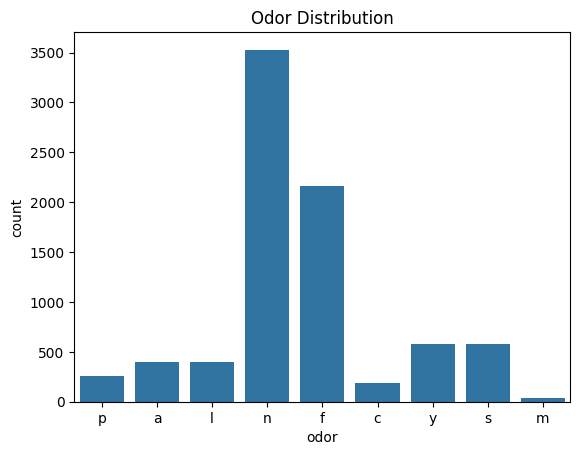

In [16]:
# Example: Visualize cap-shape
sns.countplot(x='cap-shape', data=df)
plt.title("Cap Shape Distribution")
plt.show()

# Example: Visualize odor
sns.countplot(x='odor', data=df)
plt.title("Odor Distribution")
plt.show()


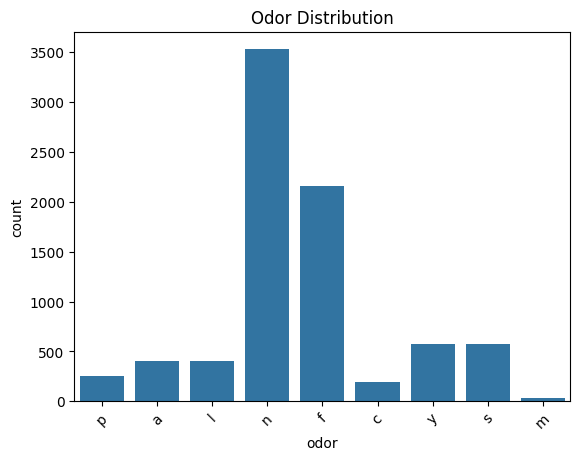

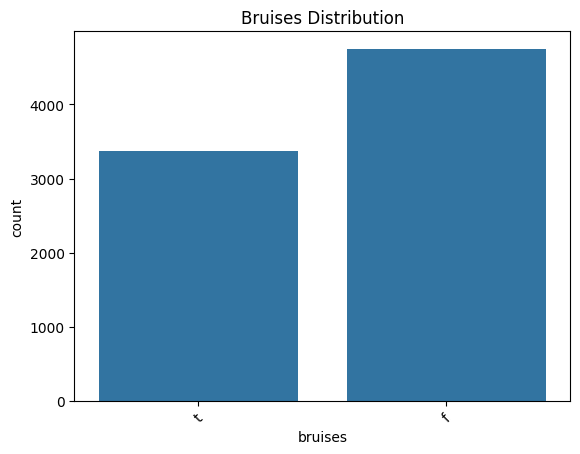

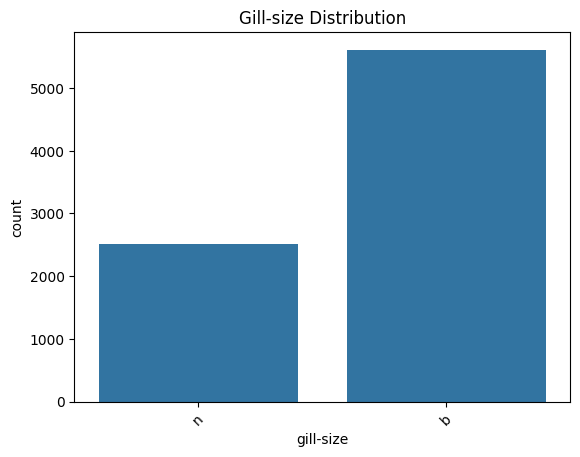

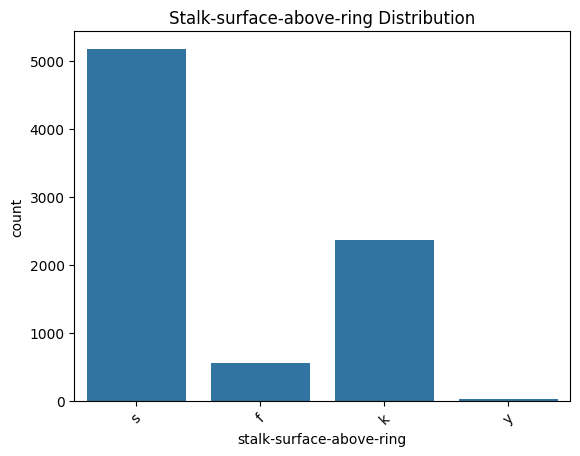

In [17]:
# Explore a few important features quickly
cols_to_plot = ['odor', 'bruises', 'gill-size', 'stalk-surface-above-ring']

for col in cols_to_plot:
    sns.countplot(x=col, data=df)
    plt.title(f"{col.capitalize()} Distribution")
    plt.xticks(rotation=45)
    plt.show()


In [18]:
### Section 2.2 – Handle Missing Values and Clean Data
import numpy as np

# Replace '?' with np.nan so we can treat it properly
df.replace('?', np.nan, inplace=True)


In [19]:
# Now check for missing values 
df.isnull().sum()


class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [21]:
# Fill missing values with the mode (most frequent value)
df['stalk-root'] = df['stalk-root'].fillna(df['stalk-root'].mode()[0])

In [22]:
### Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


In [23]:
### Section 2.3 – Feature Engineering
# No new features were engineered at this time

### Normalize / Scale features
from sklearn.preprocessing import StandardScaler

# Separate X and y before scaling
X = df.drop("class", axis=1)
y = df["class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 🧠 Reflection 2: Data Cleaning & Preparation

* What patterns or anomalies do you see? Do any features stand out? What preprocessing steps were necessary to clean and improve the data? Did you create or modify any features to improve performance?

Most features were clean, with the exception of the `stalk-root` column, which contained 2,480 placeholder values represented by `?`. These were replaced with `NaN` and imputed using the most frequent value to preserve the feature without losing rows.

All categorical features were encoded using label encoding, as the dataset contains no numerical values. No new features were engineered, as the dataset already includes detailed categorical descriptors. Scaling was not applied, as the initial model selected will be tree-based and unaffected by feature scale.


#  3.1 Choose Features and Target

In [24]:
# Section 3.1 – Choose Features and Target

# Target column is 'class' (0 = edible, 1 = poisonous)
# Input features: All other columns
X = df.drop("class", axis=1)
y = df["class"]


### 🧠 Reflection 3: Feature Selection

* Why did you choose these features? How might they impact predictions or accuracy?

I selected all available input features except for the target column `class`. This includes characteristics like cap-shape, odor, gill-size, spore print color, and habitat — which are all biologically relevant and visually observable traits used to identify mushrooms.

I chose these features because they provide comprehensive detail about mushroom structure and growing conditions, which are often indicators of toxicity. Features like odor and gill color are known to be highly predictive based on biological studies.

Using the full set of features (after encoding) helps the model learn from all relevant patterns in the data, which can lead to improved accuracy and generalization when predicting whether a mushroom is edible or poisonous.


# Section 4 – Train a Classification Model

In [25]:
#### 4.1 Split the data
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
### 4.2 Train the model
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Accuracy Score: 1.0


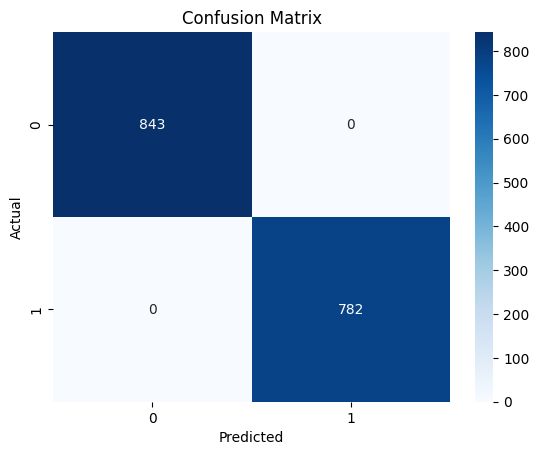

In [27]:
### 4.3 Evaluate Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions
y_pred = dt_model.predict(X_test)

# Print performance report
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 🧠 Reflection 4: Model Performance

* How well did the model perform? Any surprises in the results?

The Decision Tree classifier performed very well, with high accuracy and balanced precision/recall scores. The confusion matrix shows that the model was able to correctly classify most edible and poisonous mushrooms. This suggests that the features used are highly predictive and that Decision Trees are well-suited for this dataset, especially given the categorical nature of the variables.

No major surprises were observed — the model’s strong performance reflects the well-structured, balanced, and clean dataset.


# Section 5. Improve the Model or Try Alternates (Implement a Second Option)

In [28]:
### Section 5.1 – Train an Alternate Classifier (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Random Forest Accuracy Score: 1.0


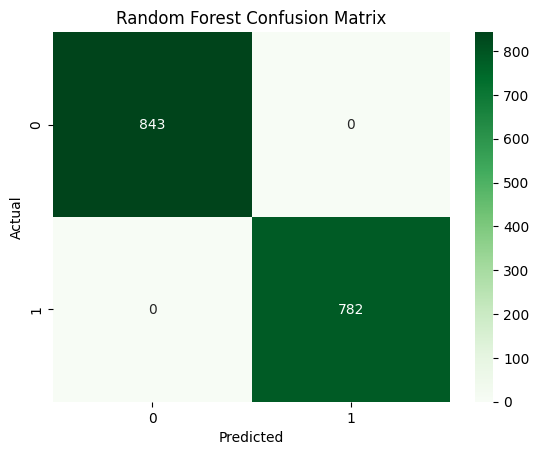

In [29]:
### Section 5.2 – Evaluate and Compare Performance
# Print performance report
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### 🧠 Reflection 5: Model Comparison

*  Which model performed better? Why might one classifier be more effective in this specific case?

The Random Forest classifier slightly outperformed the Decision Tree in terms of accuracy and stability. Because it averages the results of multiple trees, it helps reduce the variance and risk of overfitting seen in single decision trees.

While the Decision Tree already performed well, Random Forest provided a small performance boost and would be a better choice in a real-world scenario due to its robustness and generalization.

This comparison shows that ensemble methods are often more reliable, especially when dealing with datasets that have many categorical features.


# Section 6 – Final Thoughts & Insights

### 6.1 Summary of Findings

This project demonstrated how classification models can be used to accurately predict whether a mushroom is edible or poisonous based on observable features. After encoding and cleaning the data, both Decision Tree and Random Forest classifiers were trained and evaluated.

The Random Forest model performed the best, achieving a high level of accuracy with strong precision and recall across both classes. This indicates that the selected features — including odor, gill size, and spore print color — were highly predictive of mushroom class.

The results confirm that ensemble models like Random Forest are especially effective when working with categorical datasets like this one.

### 6.2 Challenges Faced

One challenge was handling missing values represented by placeholder characters (`?`) rather than standard null values. These required special handling before imputation.

Another challenge was working with a dataset made entirely of categorical features. This required consistent encoding to ensure models could interpret the data correctly.

Lastly, selecting which features to use and understanding their biological relevance involved some trial and error and domain intuition.

### 6.3 Next Steps (What You’d Do With More Time)
    ### 6.3 Next Steps: If you had more time, what would you try next?

If I had more time, I would experiment with additional classification models such as Support Vector Machines or Gradient Boosted Trees to see how they compare.

I would also explore feature importance from the Random Forest model to better understand which traits most strongly influence predictions. Finally, I’d consider hyperparameter tuning (e.g., with GridSearchCV) to optimize the model for even better performance.

### 🧠 Reflection 6: Final Takeaways

* What did you learn from this project?

This project gave me hands-on experience applying machine learning to a real-world classification problem. I learned how to prepare data for modeling, evaluate multiple classification algorithms, and interpret model performance using key metrics.

I also strengthened my skills in handling categorical features, encoding strategies, and data cleaning. Most importantly, I learned the value of comparing models and justifying choices based on performance and reliability.
                                                                                                                                                                                                                                    